In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:

text = [ 'All that we are is the result of what we have thought',
         'To be or not to be that is the question',
         'Be yourself everyone else is already taken' ]

text

['All that we are is the result of what we have thought',
 'To be or not to be that is the question',
 'Be yourself everyone else is already taken']

In [3]:
allwords = [re.split(r'\s', sentence) for sentence in text]
allwords = np.concat(allwords)
allwords = [word.lower() for word in allwords]
allwords = sorted(set(allwords))

allwords

['all',
 'already',
 'are',
 'be',
 'else',
 'everyone',
 'have',
 'is',
 'not',
 'of',
 'or',
 'question',
 'result',
 'taken',
 'that',
 'the',
 'thought',
 'to',
 'we',
 'what',
 'yourself']

In [4]:
word2idx = { word:idx for idx, word in enumerate(allwords)}
idx2word = { idx:word for idx, word in enumerate(allwords)}

print(word2idx)
print(idx2word)

{'all': 0, 'already': 1, 'are': 2, 'be': 3, 'else': 4, 'everyone': 5, 'have': 6, 'is': 7, 'not': 8, 'of': 9, 'or': 10, 'question': 11, 'result': 12, 'taken': 13, 'that': 14, 'the': 15, 'thought': 16, 'to': 17, 'we': 18, 'what': 19, 'yourself': 20}
{0: 'all', 1: 'already', 2: 'are', 3: 'be', 4: 'else', 5: 'everyone', 6: 'have', 7: 'is', 8: 'not', 9: 'of', 10: 'or', 11: 'question', 12: 'result', 13: 'taken', 14: 'that', 15: 'the', 16: 'thought', 17: 'to', 18: 'we', 19: 'what', 20: 'yourself'}


In [5]:
def encoder(text):
    words = re.split(r'\s', text.lower())
    indices = [word2idx[word] for word in words]
    return indices

def decoder(indices):
    words = [idx2word[idx] for idx in indices]
    text = ' '.join(words)
    return text

text_enc = encoder("all we thought we are")

print(text_enc)

text_dec = decoder(text_enc)

print(text_dec)



[0, 18, 16, 18, 2]
all we thought we are


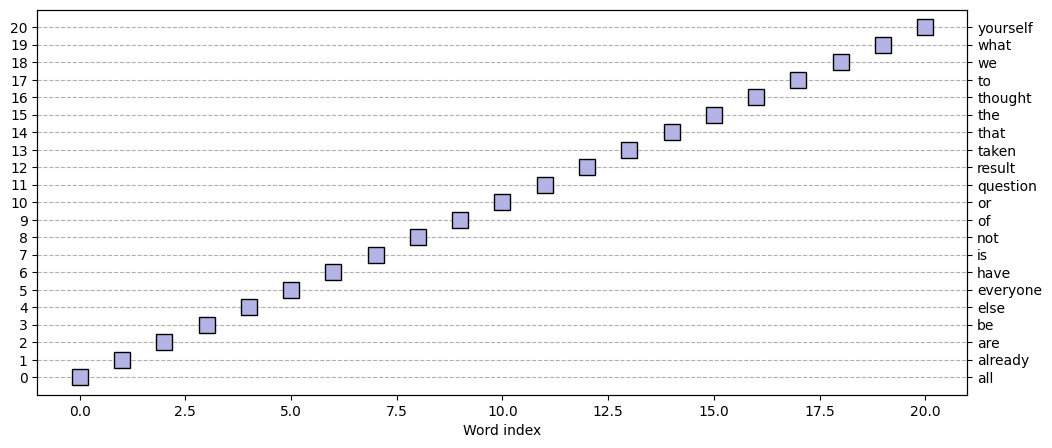

In [6]:
alltext = ' '.join(allwords)
tokens = encoder(alltext)

_, ax = plt.subplots(1, figsize=(12,5))

ax.plot(tokens, 'ks', markersize=12, markerfacecolor=[.7, .7, .9])
ax.set(xlabel='Word index', yticks=range(len(allwords)))
ax.grid(linestyle='--', axis='y')

ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(allwords)), yticklabels=allwords)

plt.show()



In [22]:
text = [ 'All that we are is the result of what we have thought',
         'To be or not to be that is the question',
         'Be yourself everyone else is already taken' ]

In [23]:
text = [re.split(r'\s', sentence.lower()) for sentence in text]
text = np.concat(text).tolist()
print(text)



['all', 'that', 'we', 'are', 'is', 'the', 'result', 'of', 'what', 'we', 'have', 'thought', 'to', 'be', 'or', 'not', 'to', 'be', 'that', 'is', 'the', 'question', 'be', 'yourself', 'everyone', 'else', 'is', 'already', 'taken']


In [24]:
searchstring = "to"

indices = [idx for idx,word in enumerate(text) if word == searchstring]

In [25]:
print(f"\"{searchstring}\" appears at indices {indices}")

for idx in indices:
    pre = text[idx - 1]
    post = text[idx + 1]
    phrase = ' '.join([pre, searchstring, post])
    print(phrase)
    print(encoder(phrase))


"to" appears at indices [12, 16]
thought to be
[16, 17, 3]
not to be
[8, 17, 3]


In [ ]:
# print(len(allwords))
# print(len(text))

one_hot_sentence = np.zeros((len(text), len(allwords)))

for i in range(len(text)):
    one_hot_sentence[i, encoder(text[i])[0]] = 1
    


# one_hot_sentence[1,3] = 1

print(one_hot_sentence)

0
14
18
2
7
15
12
9
19
18
6
16
17
3
10
8
17
3
14
7
15
11
3
20
5
4
7
1
13
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0